In [27]:
import pandas as pd
import numpy as np
import seaborn as sns

In [28]:
df = pd.read_csv('sales_data.csv')

In [29]:
df

,order_id,date,product,category,region,salesperson,quantity,unit_price,discount,total_sales
0,ORD1343,25-09-2024,Mouse,Accessories,SOUTH,Sneha,1,1570.84,0.15,1335.21
1,ORD1397,27-11-2024,Headphones,Accessories,North,Kiran,11,5082.35,0.05,53110.56
2,ORD1081,26-08-2024,Smartphone,Electronics,SOUTH,NaN,7,24769.00,0.20,138706.40
3,ORD1452,09-01-2024,Tablet,Electronics,North,Ravi,13,29913.04,0.00,388869.52
4,ORD1025,28-10-2024,Headphones,Accessories,South,Kiran,4,4782.01,0.00,19128.04
...,...,...,...,...,...,...,...,...,...,...
505,ORD1154,24-02-2024,Smartwatch,Accessories,South,Sneha,4,12599.25,0.15,42837.45
506,ORD1430,08-02-2024,Smartwatch,Accessories,north,Sneha,11,11897.07,0.15,111237.60
507,ORD1249,19-01-2024,Keyboard,Accessories,South,Arjun,14,3012.91,0.10,37962.67
508,ORD1036,26-05-2024,Keyboard,Accessories,West,Kiran,5,3127.96,0.15,13293.83


## 1. Basic Checks

In [30]:
df.head()

,order_id,date,product,category,region,salesperson,quantity,unit_price,discount,total_sales
0,ORD1343,25-09-2024,Mouse,Accessories,SOUTH,Sneha,1,1570.84,0.15,1335.21
1,ORD1397,27-11-2024,Headphones,Accessories,North,Kiran,11,5082.35,0.05,53110.56
2,ORD1081,26-08-2024,Smartphone,Electronics,SOUTH,NaN,7,24769.00,0.20,138706.40
3,ORD1452,09-01-2024,Tablet,Electronics,North,Ravi,13,29913.04,0.00,388869.52
4,ORD1025,28-10-2024,Headphones,Accessories,South,Kiran,4,4782.01,0.00,19128.04


In [31]:
df.describe()

,quantity,unit_price,discount,total_sales
count,510.000000,510.000000,483.000000,500.00000
mean,7.827451,18211.891725,0.099896,128414.77428
std,4.247458,17006.034611,0.069639,160834.72715
min,1.000000,1425.100000,0.000000,-341802.14000
25%,4.000000,3124.397500,0.050000,19330.15000
50%,8.000000,12252.590000,0.100000,55660.01500
75%,11.000000,25751.815000,0.150000,182432.96750
max,15.000000,57727.600000,0.200000,796695.76000


In [32]:
df.describe(include='O')

,order_id,date,product,category,region,salesperson
count,510,510,510,510,487,483
unique,500,276,8,2,8,5
top,ORD1087,18-08-2024,Headphones,Accessories,North,Sneha
freq,2,6,72,276,122,107


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 510 entries, 0 to 509
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   order_id     510 non-null    object 
 1   date         510 non-null    object 
 2   product      510 non-null    object 
 3   category     510 non-null    object 
 4   region       487 non-null    object 
 5   salesperson  483 non-null    object 
 6   quantity     510 non-null    int64  
 7   unit_price   510 non-null    float64
 8   discount     483 non-null    float64
 9   total_sales  500 non-null    float64
dtypes: float64(3), int64(1), object(6)
memory usage: 40.0+ KB


In [34]:
df.columns

Index(['order_id', 'date', 'product', 'category', 'region', 'salesperson',
       'quantity', 'unit_price', 'discount', 'total_sales'],
      dtype='object')

In [35]:
df.nunique()

order_id       500
date           276
product          8
category         2
region           8
salesperson      5
quantity        15
unit_price     500
discount         5
total_sales    490
dtype: int64

In [36]:
df.shape

(510, 10)

In [37]:
df.duplicated().sum()

np.int64(6)

#### Findings:
- Dataset has 510 rows and 10 columns
- Columns: order_id, date, product, category, region, salesperson, quantity, unit_price, discount, total_sales
- Mixed data types — numeric and text columns present
- Duplicate rows detected
- Missing values found in region, salesperson, discount and total_sales

### 2. Missing Values

In [38]:
df.isnull().sum()

order_id        0
date            0
product         0
category        0
region         23
salesperson    27
quantity        0
unit_price      0
discount       27
total_sales    10
dtype: int64

#### Missing values found in:
- region (~23 missing)
- salesperson (~27 missing)
- discount (~27 missing)
- total_sales (~10 missing)

region and salesperson are categorical — missing values will be replaced with mode (most frequent value)

discount and total_sales are numerical — missing values will be replaced with median

### 3. Checking Inconsistent Text

In [39]:
df['product'].unique()

array(['Mouse', 'Headphones', 'Smartphone', 'Tablet', 'Laptop',
       'Smartwatch', 'Monitor', 'Keyboard'], dtype=object)

In [40]:
df['region'].unique()

array(['SOUTH', 'North', 'South', 'East', nan, 'WEST', 'West', 'east',
       'north'], dtype=object)

In [41]:
df['salesperson'].unique()

array(['Sneha', 'Kiran', nan, 'Ravi', 'Priya', 'Arjun'], dtype=object)

In [42]:
df['category'].unique()

array(['Accessories', 'Electronics'], dtype=object)

- region column has inconsistent casing — 'north','NORTH','SOUTH','south' 'east','EAST', 'WEST','west' all refer to the same values
- All text columns will be standardized to small Case and extra whitespace will be removed
- Note: after applying str.title(), any NaN values become the string 'Nan' — these will be converted back to actual NaN before filling

### 4. Checking Invalid Numeric Values

In [43]:
# checking what unit_price actually looks like — some entries may have text in them
df['unit_price'].unique()

array([ 1570.84,  5082.35, 24769.  , 29913.04,  4782.01, 54104.12,
       24127.08, 24269.47, 24707.67, 23833.94, 12395.71, 56594.92,
       12306.69, 57345.02, 20348.71,  1562.53,  3056.93, 23968.24,
        5069.75,  3094.95, 19598.31,  3110.06, 12094.42,  4905.86,
        3028.84, 11494.84, 26180.95, 12378.94,  3137.01, 11624.52,
        3108.66, 11859.27, 53374.33, 11447.79,  4952.52,  1437.74,
       52629.1 ,  1488.28, 26209.61, 20922.94, 31297.96,  1525.07,
       31294.11, 25169.55,  3140.44,  3024.  , 28657.2 , 57360.04,
       25579.77,  1528.29, 24381.  , 11774.94, 12486.37, 11703.22,
       26186.64, 20004.08,  3087.5 , 11695.74, 19377.3 , 11759.95,
        1447.63, 57727.6 ,  3017.19, 25365.32, 11608.2 ,  1541.7 ,
       19725.2 , 31373.9 ,  1476.03, 29549.46, 12333.21,  1559.89,
        2967.76,  1520.35,  3052.91,  1457.27, 57168.2 , 57188.52,
        4837.23, 30188.52,  4960.07, 57332.72, 29207.99, 29467.98,
       29807.65, 25234.2 ,  5077.74, 24804.8 ,  1496.89,  4910

Some unit_price entries contain text like '55000 INR' instead of a plain number. Non-numeric characters will be stripped and the column will be converted to float.

In [44]:
# checking for negative or zero total_sales — these are not valid business entries
df[df['total_sales'] <= 0]

,order_id,date,product,category,region,salesperson,quantity,unit_price,discount,total_sales
72,ORD1182,07-11-2024,Mouse,Accessories,South,NaN,2,1559.89,0.10,-2807.80
184,ORD1281,06-05-2024,Headphones,Accessories,South,Ravi,8,4811.26,0.15,-32716.57
214,ORD1488,19-04-2024,Keyboard,Accessories,South,Arjun,11,2978.00,0.10,-29482.20
235,ORD1356,27-04-2024,Keyboard,Accessories,West,Kiran,5,2895.72,NaN,-13030.74
269,ORD1390,21-10-2024,Keyboard,Accessories,South,Arjun,6,2937.43,0.15,-14980.89
356,ORD1055,13-01-2024,Tablet,Electronics,South,Arjun,13,30932.32,0.15,-341802.14
418,ORD1476,24-12-2024,Smartwatch,Accessories,East,Arjun,5,12421.10,0.15,-52789.67
443,ORD1143,08-01-2024,Mouse,Accessories,South,Sneha,2,1503.89,0.15,-2556.61


In [45]:
df[df['quantity'] <= 0]

,order_id,date,product,category,region,salesperson,quantity,unit_price,discount,total_sales


- Rows with total_sales <= 0 are invalid — a sale cannot be zero or negative
- These rows will be dropped as they have no business meaning

#### Discount

In [46]:
# checking discount values — some may have been entered as 15 instead of 0.15
df['discount'].unique()

array([0.15, 0.05, 0.2 , 0.  , 0.1 ,  nan])

Discount should always be between 0 and 1 (e.g. 0.10 means 10%). Any value greater than 1 was entered as a percentage (e.g. 15) and will be divided by 100.

### 5. Outlier Check

<Axes: xlabel='total_sales'>

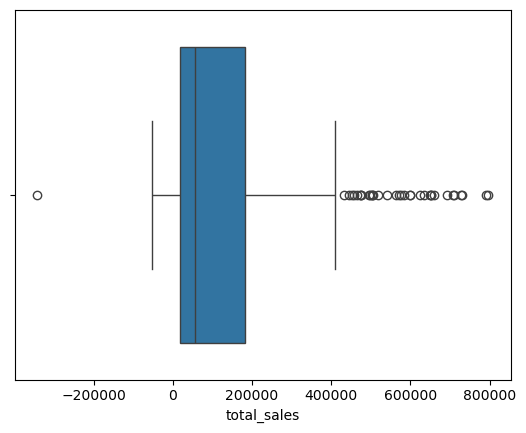

In [47]:
# visualizing distribution of total_sales to check for extreme values
sns.boxplot(x=df['total_sales'])

The boxplot shows some high total_sales values. However these are not outliers — a large Laptop order at full price is a valid high-value sale. Removing valid high sales using IQR would reduce our total_sales and skew the top_product result.

The only invalid entries are negative or zero values which will be dropped in preprocessing.

In [49]:
import sys
import os

sys.path.insert(0, os.path.abspath('../src'))

## Preprocessing

In [50]:
import pandas as pd
import numpy as np


def preprocess(filepath):

    df = pd.read_csv(filepath)

    # removing duplicate rows
    df = df.drop_duplicates()

    # converting text columns values to title case and removing extra spaces
    for col in ['product', 'region', 'salesperson', 'category']:
        df[col] = df[col].astype(str).str.strip().str.title()

    # after applying str.title(), NaN becomes the string "Nan"
    # converting it back to actual NaN so we can fill it properly
    df[['region', 'salesperson']] = df[['region', 'salesperson']].replace('Nan', np.nan)

    # filling missing categorical values with the most frequent value
    for col in ['region', 'salesperson']:
        df[col] = df[col].fillna(df[col].mode()[0])

    # cleaning unit_price first before filling nulls
    # some entries have text like "55000 INR" so we strip non-numeric characters
    df['unit_price'] = df['unit_price'].astype(str).str.replace(r'[^0-9.]', '', regex=True)
    df['unit_price'] = pd.to_numeric(df['unit_price'], errors='coerce')
    df['unit_price'] = df['unit_price'].fillna(df['unit_price'].median())

    # converting quantity and discount to numeric
    df['quantity'] = pd.to_numeric(df['quantity'], errors='coerce')
    df['discount'] = pd.to_numeric(df['discount'], errors='coerce')
    df['discount'] = df['discount'].fillna(df['discount'].median())

    # some discount values were entered as 15 instead of 0.15
    # dividing by 100 to bring them to the correct decimal format
    df.loc[df['discount'] > 1, 'discount'] /= 100

    # removing rows where quantity is zero or negative as they are not valid orders
    df = df[df['quantity'] > 0]

    # converting total_sales to numeric and removing negative or zero values
    # negative sales have no business meaning so we drop them
    df['total_sales'] = pd.to_numeric(df['total_sales'], errors='coerce')
    df = df[df['total_sales'] > 0]
    df['total_sales'] = df['total_sales'].fillna(df['total_sales'].median())

    # converting the date column to datetime format
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df = df.dropna(subset=['date'])

    # keeping only the columns needed for analysis
    df = df[['date', 'product', 'region', 'total_sales']]

    # dropping duplicates again after column selection
    # two rows might look different with all columns but become identical once we trim down to 4
    df = df.drop_duplicates()

    df = df.reset_index(drop=True)

    return df

from preprocessor import preprocess

df = preprocess("data/sales_data.csv")
df.to_csv("data/cleaned_sales_data.csv", index=False)    

ModuleNotFoundError: No module named 'preprocessor'

In [51]:
import os
print(os.getcwd())

C:\Users\dharm\ai-business-intelligence-agent\ml\TeamA\notebooks\for exploration


In [ ]:
df = preprocess("sales_data.csv")

print("Shape:", df.shape)
print("Missing values:\n", df.isnull().sum())
print("Duplicates:", df.duplicated().sum())
print("Negative total_sales:", (df["total_sales"] <= 0).sum())

In [ ]:
df

After preprocessing:
- All duplicates removed
- No missing values remaining
- All text columns standardized to Title Case
- Invalid rows (negative/zero total_sales, zero quantity) dropped
- Only relevant columns retained: date, product, region, total_sales